In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [2]:
df = pd.read_csv('../data/raw/Sample - Superstore.csv', 
                 encoding='windows-1252')
print("Dataset loaded successfully! ✅")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Dataset loaded successfully! ✅
Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("=== DATASET INFO ===")
print(f"Total Orders: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values! ✅")

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== DATASET INFO ===
Total Orders: 9994
Total Columns: 21

=== MISSING VALUES ===
No missing values! ✅

=== DUPLICATES ===
Duplicate rows: 0

=== DATA TYPES ===
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [5]:
# Convert dates to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful date features
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Calculate Profit Margin
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

print("✅ Date columns converted!")
print(f"✅ Delivery Days created — Min: {df['Delivery Days'].min()}, Max: {df['Delivery Days'].max()}")
print(f"✅ Profit Margin created — Avg: {df['Profit Margin %'].mean():.2f}%")
print(f"\nYear range: {df['Order Year'].min()} to {df['Order Year'].max()}")

# Save cleaned data
df.to_csv('../data/processed/superstore_cleaned.csv', index=False)
print("\n✅ Cleaned data saved!")

✅ Date columns converted!
✅ Delivery Days created — Min: 0, Max: 7
✅ Profit Margin created — Avg: 12.03%

Year range: 2014 to 2017

✅ Cleaned data saved!


C:\Users\vaish\AppData\Local\Temp\ipykernel_14672\1647646757.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values,


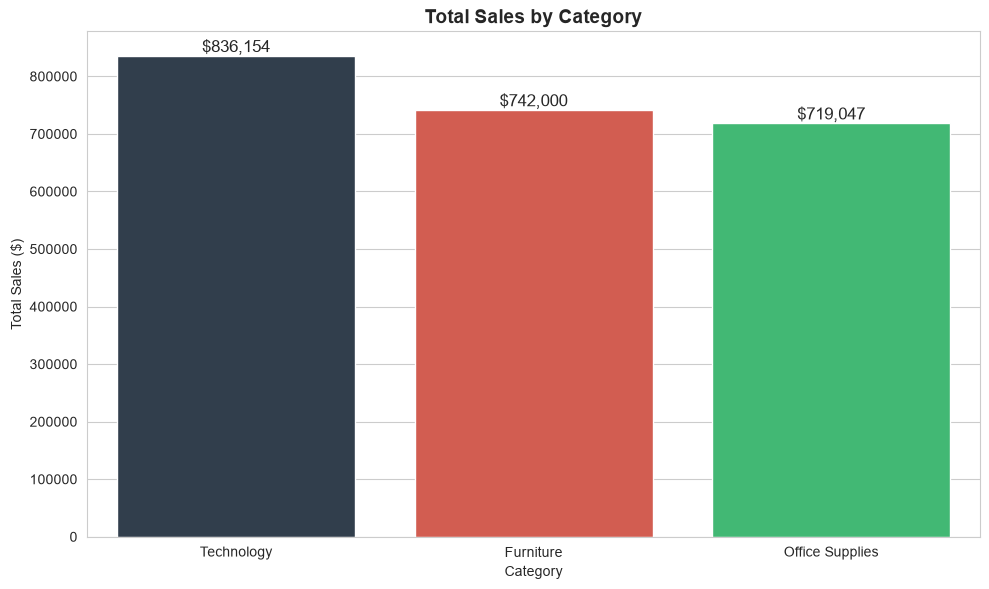


Top Category: Technology with $836,154 in sales


In [6]:
plt.figure(figsize=(10,6))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

sns.barplot(x=category_sales.index, y=category_sales.values, 
            palette=['#2C3E50','#E74C3C','#2ECC71'])
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')

for p in plt.gca().patches:
    plt.gca().annotate(f'${p.get_height():,.0f}',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/01_sales_by_category.png', dpi=150)
plt.show()

print(f"\nTop Category: {category_sales.index[0]} with ${category_sales.values[0]:,.0f} in sales")

C:\Users\vaish\AppData\Local\Temp\ipykernel_14672\725549652.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values,


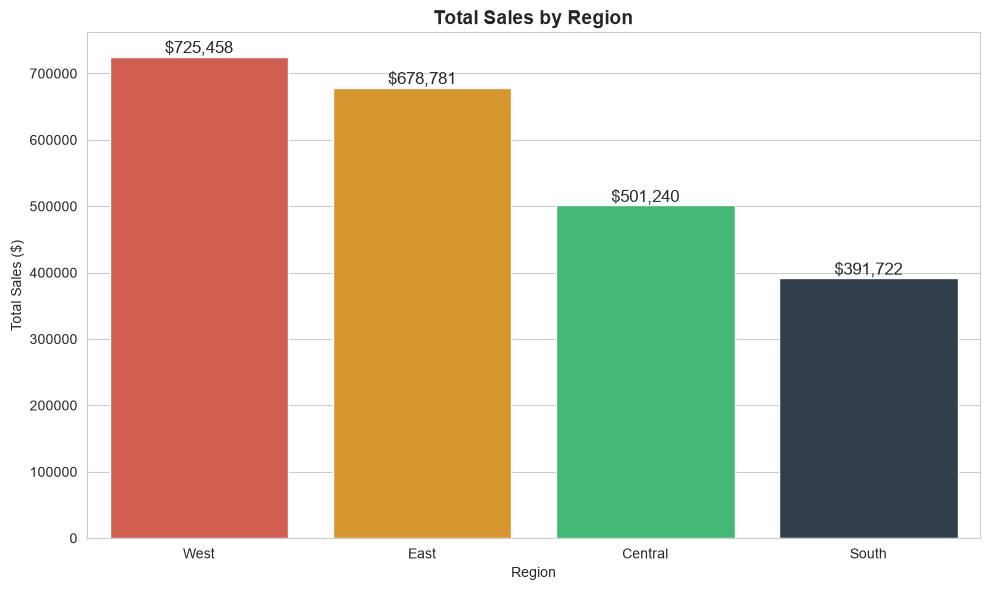


Top Region: West with $725,458 in sales


In [7]:
plt.figure(figsize=(10,6))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

sns.barplot(x=region_sales.index, y=region_sales.values,
            palette=['#E74C3C','#F39C12','#2ECC71','#2C3E50'])
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')

for p in plt.gca().patches:
    plt.gca().annotate(f'${p.get_height():,.0f}',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/02_sales_by_region.png', dpi=150)
plt.show()

print(f"\nTop Region: {region_sales.index[0]} with ${region_sales.values[0]:,.0f} in sales")

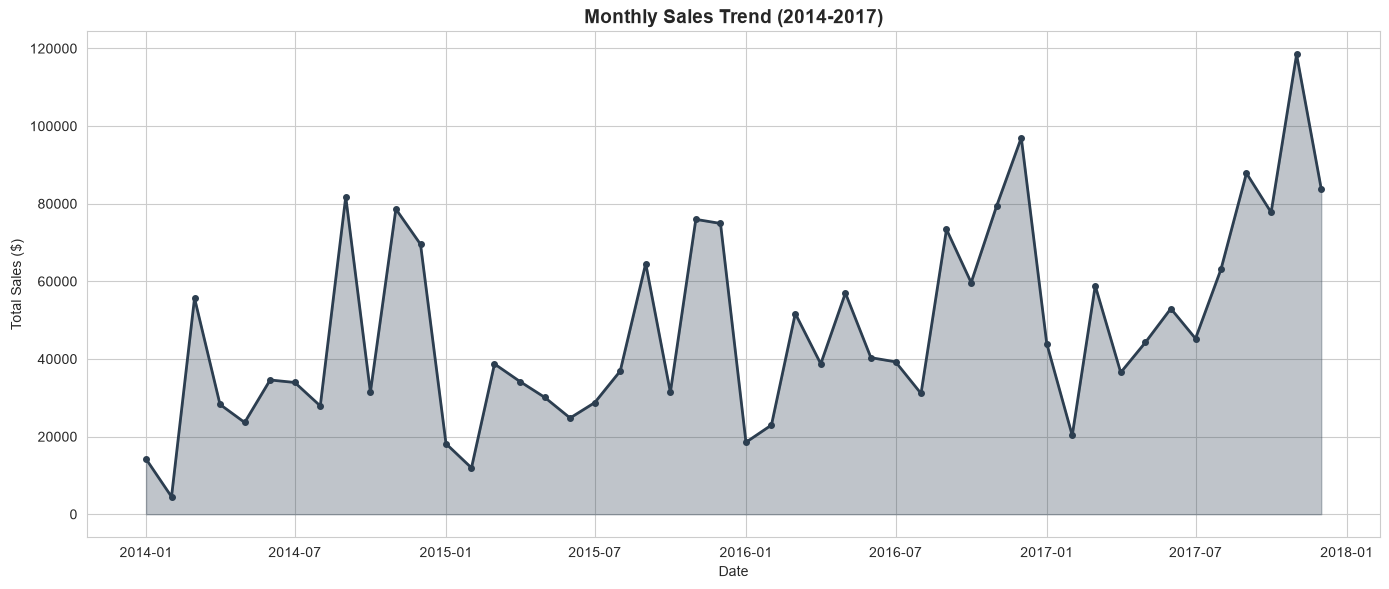

Peak Sales Month: Year 2017, Month 11 — $118,448


In [8]:
plt.figure(figsize=(14,6))
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Order Year', 'Order Month']].assign(day=1).rename(columns={'Order Year':'year','Order Month':'month'}))

plt.plot(monthly_sales['Date'], monthly_sales['Sales'], 
         color='#2C3E50', linewidth=2, marker='o', markersize=4)
plt.fill_between(monthly_sales['Date'], monthly_sales['Sales'], 
                 alpha=0.3, color='#2C3E50')
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/03_monthly_sales_trend.png', dpi=150)
plt.show()

# Find peak month
peak = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
print(f"Peak Sales Month: Year {int(peak['Order Year'])}, Month {int(peak['Order Month'])} — ${peak['Sales']:,.0f}")

### Key Finding 3 — Seasonal Demand
- Peak sales month: November 2017
- Holiday season (Oct-Nov) drives highest demand
- Supply chain must prepare 2 months in advance!

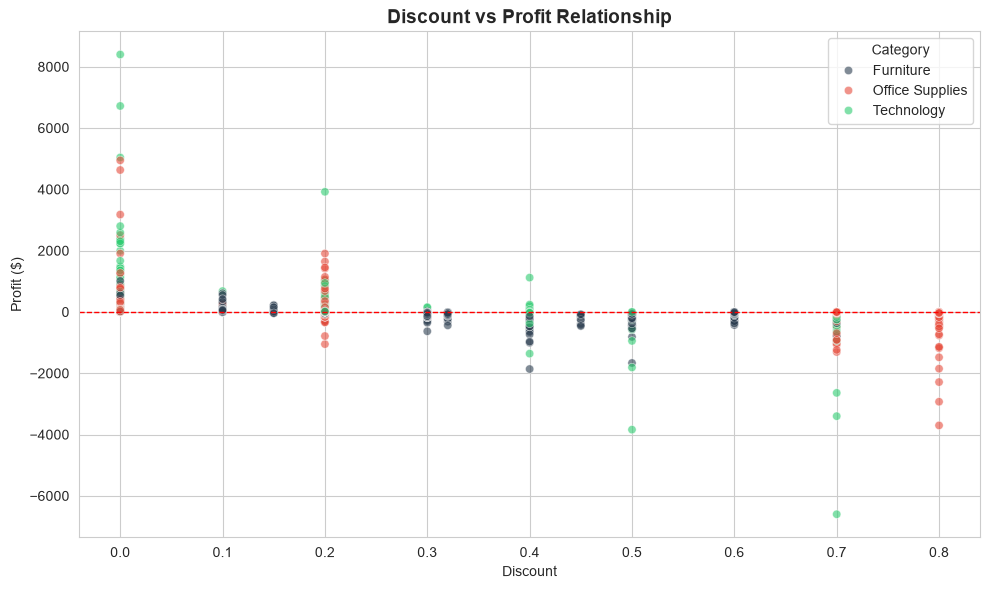

Correlation between Discount and Profit: -0.219


In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit',
                hue='Category',
                palette=['#2C3E50','#E74C3C','#2ECC71'],
                alpha=0.6)
plt.title('Discount vs Profit Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../outputs/04_discount_vs_profit.png', dpi=150)
plt.show()

# Correlation
corr = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {corr:.3f}")

### Key Finding 4 — Discount Impact
- Correlation between Discount and Profit: -0.219
- High discounts (>40%) consistently cause losses
- Company should cap discounts at 20% maximum!

C:\Users\vaish\AppData\Local\Temp\ipykernel_14672\200151861.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index,


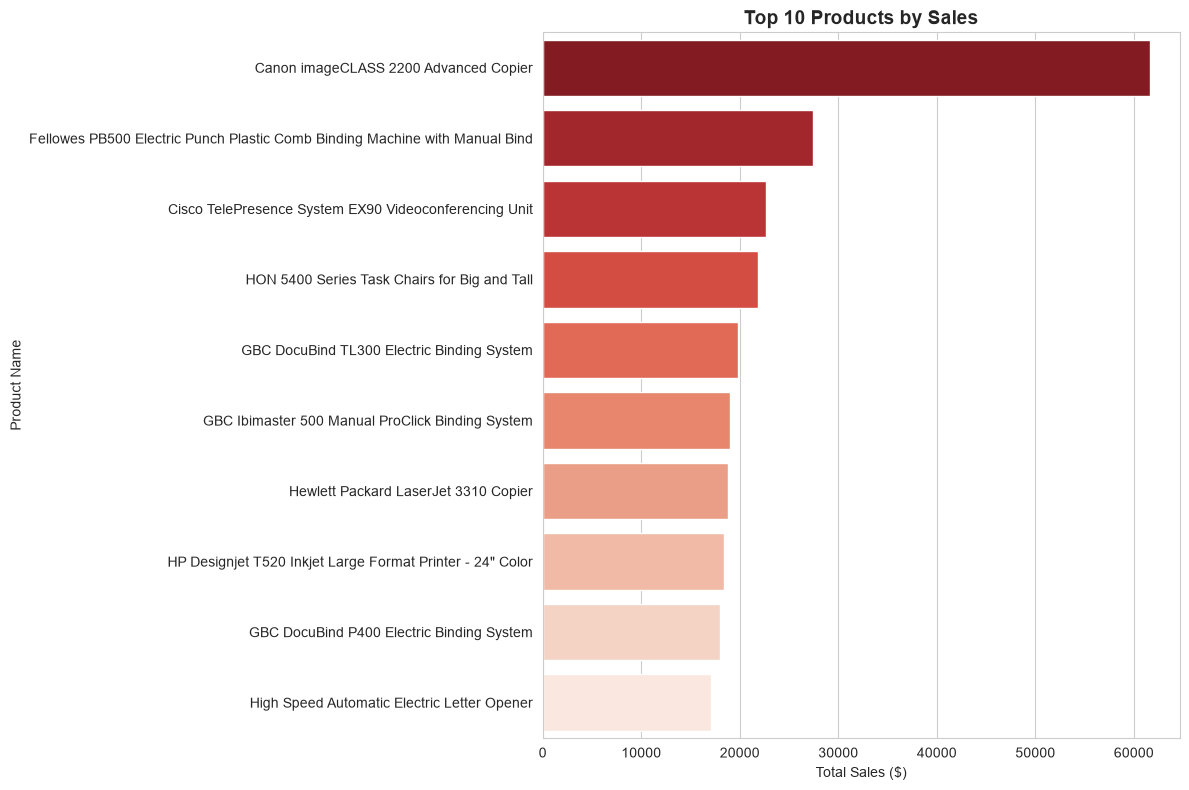

Top 3 Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
Name: Sales, dtype: float64


In [10]:
plt.figure(figsize=(12,8))
top_products = df.groupby('Product Name')['Sales'].sum()\
                 .sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index,
            palette='Reds_r')
plt.title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.savefig('../outputs/05_top10_products.png', dpi=150)
plt.show()

print("Top 3 Products:")
print(top_products.head(3))

### Key Finding 5 — Top Products
- Canon imageCLASS 2200 = #1 product ($61,599)
- All top 3 products are Technology category
- These are critical stock items — zero stockout tolerance!

C:\Users\vaish\AppData\Local\Temp\ipykernel_14672\2061246273.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_products.values, y=loss_products.index,


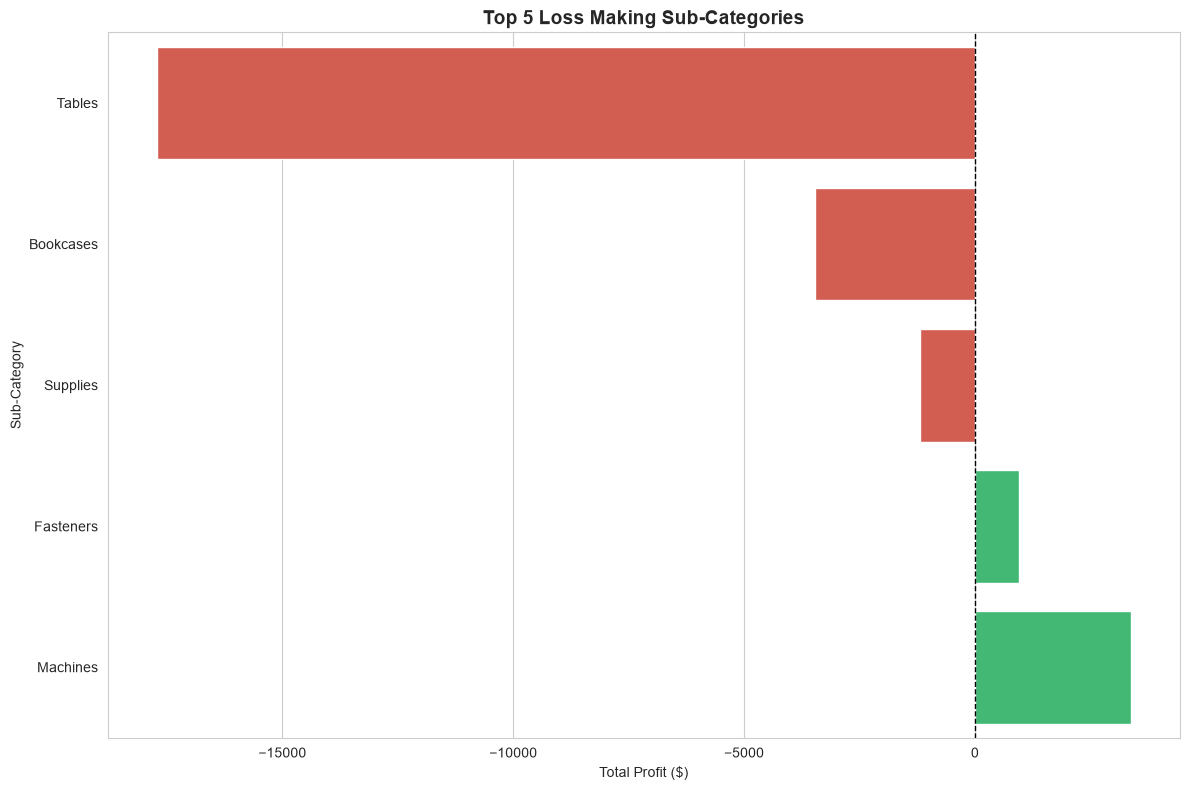

Loss Making Sub-Categories:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


In [11]:
plt.figure(figsize=(12,8))
loss_products = df.groupby('Sub-Category')['Profit'].sum()\
                  .sort_values(ascending=True).head(5)

colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in loss_products.values]
sns.barplot(x=loss_products.values, y=loss_products.index,
            palette=colors)
plt.title('Top 5 Loss Making Sub-Categories', 
          fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../outputs/06_loss_making_products.png', dpi=150)
plt.show()

print("Loss Making Sub-Categories:")
print(loss_products[loss_products < 0])

### Key Finding 6 — Loss Making Products
- Tables, Bookcases and Supplies are loss making!
- Company should reduce discounts on these items
- Or consider discontinuing from product catalog
- Redirecting budget to Technology products would increase profit!

C:\Users\vaish\AppData\Local\Temp\ipykernel_14672\2413887090.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Profit_Margin_%',


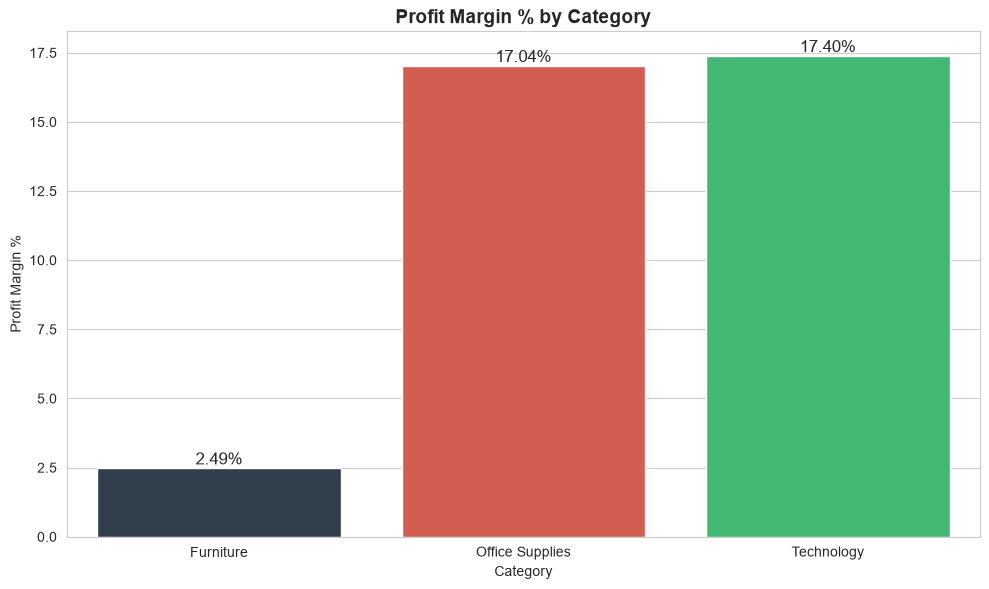


Profit Margin by Category:
          Category  Profit_Margin_%
0        Furniture             2.49
1  Office Supplies            17.04
2       Technology            17.40


In [12]:
plt.figure(figsize=(10,6))
category_profit = df.groupby('Category').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum')
).reset_index()
category_profit['Profit_Margin_%'] = (category_profit['Total_Profit'] / 
                                       category_profit['Total_Sales'] * 100).round(2)

sns.barplot(x='Category', y='Profit_Margin_%', 
            data=category_profit,
            palette=['#2C3E50','#E74C3C','#2ECC71'])
plt.title('Profit Margin % by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Profit Margin %')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}%',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/07_profit_margin_by_category.png', dpi=150)
plt.show()

print("\nProfit Margin by Category:")
print(category_profit[['Category','Profit_Margin_%']])

### Key Finding 7 — Profit Margin
- Technology = highest profit margin
- Technology = highest sales
- Technology is the most valuable category!
- Supply chain focus should be on Technology products!

C:\Users\vaish\AppData\Local\Temp\ipykernel_14672\824595866.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery.index, y=delivery.values,


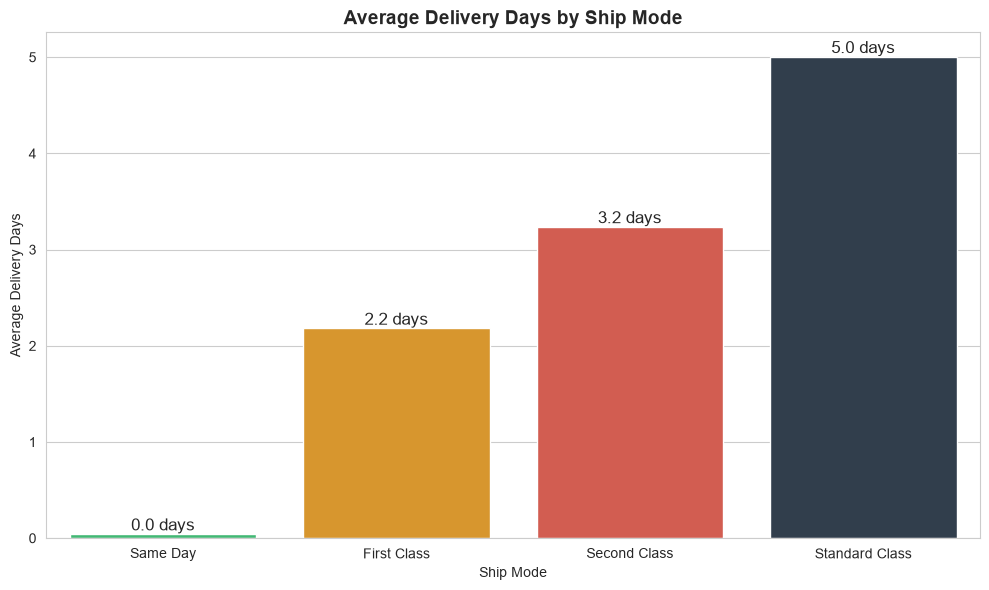


Average Delivery Days by Ship Mode:
Ship Mode
Same Day          0.044199
First Class       2.182705
Second Class      3.238046
Standard Class    5.006535
Name: Delivery Days, dtype: float64


In [13]:
plt.figure(figsize=(10,6))
delivery = df.groupby('Ship Mode')['Delivery Days'].mean().sort_values()

sns.barplot(x=delivery.index, y=delivery.values,
            palette=['#2ECC71','#F39C12','#E74C3C','#2C3E50'])
plt.title('Average Delivery Days by Ship Mode', 
          fontsize=14, fontweight='bold')
plt.xlabel('Ship Mode')
plt.ylabel('Average Delivery Days')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f} days',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/08_delivery_days.png', dpi=150)
plt.show()

print("\nAverage Delivery Days by Ship Mode:")
print(delivery)

### Key Finding 8 — Delivery Analysis
- Standard Class = 5 days average delivery
- Same Day = almost instant (0.04 days)
- Optimizing Standard Class logistics = biggest impact
- Faster delivery = higher customer retention!

C:\Users\vaish\AppData\Local\Temp\ipykernel_14672\4097150480.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Profit_Margin_%',


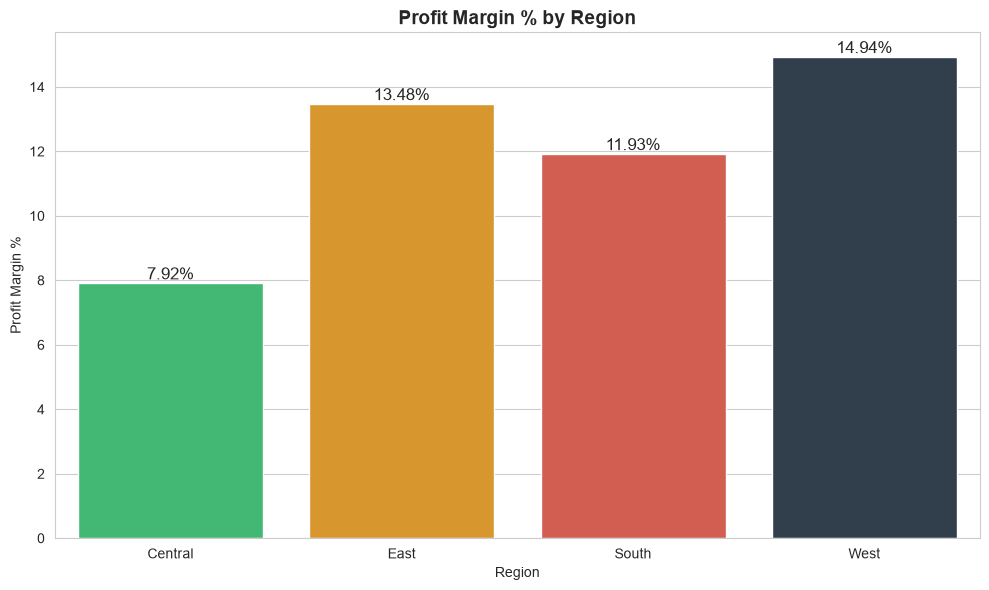


Regional Profit Analysis:
    Region  Total_Sales  Total_Profit  Profit_Margin_%
0  Central  501239.8908    39706.3625             7.92
1     East  678781.2400    91522.7800            13.48
2    South  391721.9050    46749.4303            11.93
3     West  725457.8245   108418.4489            14.94


In [14]:
plt.figure(figsize=(10,6))
region_profit = df.groupby('Region').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum')
).reset_index()
region_profit['Profit_Margin_%'] = (region_profit['Total_Profit'] /
                                     region_profit['Total_Sales'] * 100).round(2)

sns.barplot(x='Region', y='Profit_Margin_%',
            data=region_profit,
            palette=['#2ECC71','#F39C12','#E74C3C','#2C3E50'])
plt.title('Profit Margin % by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Profit Margin %')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}%',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/09_regional_profit.png', dpi=150)
plt.show()

print("\nRegional Profit Analysis:")
print(region_profit[['Region','Total_Sales','Total_Profit','Profit_Margin_%']])

### Key Finding 9 — Regional Performance
- West region = highest sales + highest profit margin
- West is the most valuable region overall
- Priority warehouse stocking should be in West region!

# 📊 Supply Chain Analytics — Key Findings

### Key Finding 1 — Sales by Category
- Technology has highest sales overall
- Focus supply chain on Technology products!

### Key Finding 2 — Regional Performance
- West region has highest sales
- Priority stock allocation should go to West!

### Key Finding 3 — Seasonal Demand
- Peak sales month: November 2017
- Holiday season (Oct-Nov) drives highest demand
- Prepare supply chain 2 months in advance!

### Key Finding 4 — Discount Impact
- Correlation between Discount and Profit: -0.219
- High discounts (>40%) consistently cause losses
- Cap discounts at 20% maximum!

### Key Finding 5 — Top Products
- Canon imageCLASS 2200 = #1 product ($61,599)
- All top 3 products are Technology category
- Zero stockout tolerance for these items!

### Key Finding 6 — Loss Making Products
- Tables, Bookcases and Supplies are loss making!
- Reduce discounts or discontinue these products
- Redirect budget to Technology products!

### Key Finding 7 — Profit Margin
- Technology = highest profit margin
- Technology is the most valuable category!

### Key Finding 8 — Delivery Analysis
- Standard Class = 5 days average delivery
- Optimizing Standard Class = biggest impact
- Faster delivery = higher customer retention!

### Key Finding 9 — Regional Profit
- West region = highest profit margin
- Priority warehouse stocking in West region!

In [15]:
import sqlite3

# Load cleaned data
df = pd.read_csv('../data/processed/superstore_cleaned.csv')

# Create SQLite database
conn = sqlite3.connect('../data/processed/superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

print("✅ SQLite database created!")
print("✅ Data loaded into 'orders' table!")
print(f"✅ Total records: {len(df)}")

✅ SQLite database created!
✅ Data loaded into 'orders' table!
✅ Total records: 9994


In [16]:
query1 = """
SELECT 
    Category,
    ROUND(SUM(Sales), 2) as Total_Sales,
    ROUND(SUM(Profit), 2) as Total_Profit,
    ROUND(SUM(Profit)/SUM(Sales)*100, 2) as Profit_Margin_Percent
FROM orders
GROUP BY Category
ORDER BY Total_Sales DESC
"""

result1 = pd.read_sql_query(query1, conn)
print("=== SALES & PROFIT BY CATEGORY ===")
print(result1)

=== SALES & PROFIT BY CATEGORY ===
          Category  Total_Sales  Total_Profit  Profit_Margin_Percent
0       Technology    836154.03     145454.95                  17.40
1        Furniture    741999.80      18451.27                   2.49
2  Office Supplies    719047.03     122490.80                  17.04


In [17]:
query2 = """
SELECT 
    "Product Name",
    ROUND(SUM(Sales), 2) as Total_Sales,
    ROUND(SUM(Profit), 2) as Total_Profit,
    SUM(Quantity) as Total_Quantity
FROM orders
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10
"""

result2 = pd.read_sql_query(query2, conn)
print("=== TOP 10 PRODUCTS BY REVENUE ===")
print(result2)

=== TOP 10 PRODUCTS BY REVENUE ===
                                        Product Name  Total_Sales  \
0              Canon imageCLASS 2200 Advanced Copier     61599.82   
1  Fellowes PB500 Electric Punch Plastic Comb Bin...     27453.38   
2  Cisco TelePresence System EX90 Videoconferenci...     22638.48   
3       HON 5400 Series Task Chairs for Big and Tall     21870.58   
4         GBC DocuBind TL300 Electric Binding System     19823.48   
5   GBC Ibimaster 500 Manual ProClick Binding System     19024.50   
6               Hewlett Packard LaserJet 3310 Copier     18839.69   
7  HP Designjet T520 Inkjet Large Format Printer ...     18374.90   
8          GBC DocuBind P400 Electric Binding System     17965.07   
9        High Speed Automatic Electric Letter Opener     17030.31   

   Total_Profit  Total_Quantity  
0      25199.93              20  
1       7753.04              31  
2      -1811.08               6  
3          0.00              39  
4       2233.51              37  
5

In [18]:
query3 = """
SELECT 
    "Order Year",
    "Order Month",
    ROUND(SUM(Sales), 2) as Monthly_Sales,
    ROUND(SUM(Profit), 2) as Monthly_Profit,
    COUNT(*) as Total_Orders
FROM orders
GROUP BY "Order Year", "Order Month"
ORDER BY "Order Year", "Order Month"
"""

result3 = pd.read_sql_query(query3, conn)
print("=== MONTHLY SALES TREND ===")
print(result3)

=== MONTHLY SALES TREND ===
    Order Year  Order Month  Monthly_Sales  Monthly_Profit  Total_Orders
0         2014            1       14236.90         2450.19            79
1         2014            2        4519.89          862.31            46
2         2014            3       55691.01          498.73           157
3         2014            4       28295.35         3488.84           135
4         2014            5       23648.29         2738.71           122
5         2014            6       34595.13         4976.52           135
6         2014            7       33946.39         -841.48           143
7         2014            8       27909.47         5318.10           153
8         2014            9       81777.35         8328.10           268
9         2014           10       31453.39         3448.26           159
10        2014           11       78628.72         9292.13           318
11        2014           12       69545.62         8983.57           278
12        2015         

In [19]:
query4 = """
SELECT 
    "Sub-Category",
    ROUND(SUM(Sales), 2) as Total_Sales,
    ROUND(SUM(Profit), 2) as Total_Profit,
    ROUND(SUM(Profit)/SUM(Sales)*100, 2) as Profit_Margin_Percent
FROM orders
GROUP BY "Sub-Category"
HAVING Total_Profit < 0
ORDER BY Total_Profit ASC
"""

result4 = pd.read_sql_query(query4, conn)
print("=== LOSS MAKING SUB-CATEGORIES ===")
print(result4)

=== LOSS MAKING SUB-CATEGORIES ===
  Sub-Category  Total_Sales  Total_Profit  Profit_Margin_Percent
0       Tables    206965.53     -17725.48                  -8.56
1    Bookcases    114880.00      -3472.56                  -3.02
2     Supplies     46673.54      -1189.10                  -2.55


In [20]:
query5 = """
SELECT 
    Region,
    COUNT(*) as Total_Orders,
    ROUND(SUM(Sales), 2) as Total_Sales,
    ROUND(SUM(Profit), 2) as Total_Profit,
    ROUND(SUM(Profit)/SUM(Sales)*100, 2) as Profit_Margin_Percent
FROM orders
GROUP BY Region
ORDER BY Total_Profit DESC
"""

result5 = pd.read_sql_query(query5, conn)
print("=== REGIONAL PERFORMANCE ===")
print(result5)

=== REGIONAL PERFORMANCE ===
    Region  Total_Orders  Total_Sales  Total_Profit  Profit_Margin_Percent
0     West          3203    725457.82     108418.45                  14.94
1     East          2848    678781.24      91522.78                  13.48
2    South          1620    391721.91      46749.43                  11.93
3  Central          2323    501239.89      39706.36                   7.92


In [21]:
query6 = """
SELECT 
    CASE 
        WHEN Discount = 0 THEN 'No Discount'
        WHEN Discount <= 0.2 THEN 'Low (0-20%)'
        WHEN Discount <= 0.4 THEN 'Medium (20-40%)'
        ELSE 'High (>40%)'
    END as Discount_Category,
    COUNT(*) as Total_Orders,
    ROUND(SUM(Sales), 2) as Total_Sales,
    ROUND(SUM(Profit), 2) as Total_Profit
FROM orders
GROUP BY Discount_Category
ORDER BY Total_Profit DESC
"""

result6 = pd.read_sql_query(query6, conn)
print("=== DISCOUNT IMPACT ON PROFIT ===")
print(result6)

=== DISCOUNT IMPACT ON PROFIT ===
  Discount_Category  Total_Orders  Total_Sales  Total_Profit
0       No Discount          4798   1087908.47     320987.60
1       Low (0-20%)          3803    846522.24     100785.47
2   Medium (20-40%)           460    234137.90     -35817.47
3       High (>40%)           933    128632.25     -99558.59


In [23]:
# Save all results to CSV
result1.to_csv('../outputs/sql_category_analysis.csv', index=False)
result2.to_csv('../outputs/sql_top_products.csv', index=False)
result3.to_csv('../outputs/sql_monthly_trend.csv', index=False)
result4.to_csv('../outputs/sql_loss_products.csv', index=False)
result5.to_csv('../outputs/sql_regional_performance.csv', index=False)
result6.to_csv('../outputs/sql_discount_impact.csv', index=False)
print("✅ Dataset loaded: 9,994 orders")
print("✅ Data cleaned and prepared")
print("✅ 9 EDA charts created")
print("✅ 9 Key findings documented")
print("✅ 6 SQL queries completed")

✅ Dataset loaded: 9,994 orders
✅ Data cleaned and prepared
✅ 9 EDA charts created
✅ 9 Key findings documented
✅ 6 SQL queries completed
